# 🧠 Word2Vec — Explained Visually

**Word2Vec** is a technique developed by Tomas Mikolov et al. at Google in 2013. It turns words into dense numerical vectors (embeddings) such that words with similar meanings end up **close together** in vector space.

### The Core Intuition
> *"You shall know a word by the company it keeps."* — J.R. Firth, 1957

Word2Vec learns word meanings by looking at **context** — the words that appear nearby. If two words frequently appear in similar contexts, they get similar vectors.

### Two Architectures

| | **CBOW** (Continuous Bag of Words) | **Skip-gram** |
|---|---|---|
| **Input** | Context words (surrounding words) | Target word (center word) |
| **Output** | Predicts the center word | Predicts the context words |
| **Best for** | Frequent words, faster training | Rare words, smaller datasets |

```
CBOW:        [the] [cat] [___] [on] [mat]  →  predicts "sat"
Skip-gram:              [sat]               →  predicts "the", "cat", "on", "mat"
```

### What You Get
Each word becomes a vector like: `king = [0.2, -0.4, 0.7, 0.1, ...]` (typically 100-300 dimensions)

These vectors capture semantic relationships through **vector arithmetic**:
$$\vec{king} - \vec{man} + \vec{woman} \approx \vec{queen}$$

Let's see it in action! 👇

## 1. Import Required Libraries

In [1]:
# Core libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Word2Vec model
from gensim.models import Word2Vec

# Dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

# Make plots look nice
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


## 2. Prepare a Text Corpus

We need a decent amount of text for Word2Vec to learn meaningful relationships. Let's create a corpus with sentences about various topics — animals, royalty, food, technology — so we can see how the model groups related concepts together.

In [2]:
# A rich corpus with multiple topics so Word2Vec can learn semantic clusters
sentences = [
    # Royalty & Gender
    ["king", "queen", "prince", "princess", "throne", "kingdom", "royal", "crown", "palace"],
    ["king", "rules", "the", "kingdom", "from", "his", "throne"],
    ["queen", "rules", "the", "kingdom", "with", "grace", "and", "wisdom"],
    ["the", "prince", "and", "princess", "live", "in", "the", "palace"],
    ["the", "king", "is", "a", "man", "who", "wears", "the", "crown"],
    ["the", "queen", "is", "a", "woman", "who", "wears", "the", "crown"],
    ["man", "and", "woman", "are", "equal", "in", "the", "kingdom"],
    ["the", "prince", "is", "a", "young", "man", "of", "royal", "blood"],
    ["the", "princess", "is", "a", "young", "woman", "of", "royal", "blood"],
    ["king", "and", "queen", "sit", "on", "the", "throne", "together"],

    # Animals
    ["cat", "kitten", "dog", "puppy", "pet", "animal", "fur", "paw"],
    ["the", "cat", "chased", "the", "mouse", "across", "the", "room"],
    ["the", "dog", "barked", "at", "the", "cat", "in", "the", "yard"],
    ["a", "kitten", "is", "a", "young", "cat", "with", "soft", "fur"],
    ["a", "puppy", "is", "a", "young", "dog", "that", "loves", "to", "play"],
    ["cats", "and", "dogs", "are", "popular", "pets", "around", "the", "world"],
    ["the", "cat", "sat", "on", "the", "mat", "and", "purred"],
    ["the", "dog", "fetched", "the", "ball", "in", "the", "park"],
    ["animal", "lovers", "adopt", "cats", "dogs", "and", "other", "pets"],

    # Food & Cooking
    ["apple", "banana", "orange", "fruit", "juice", "fresh", "healthy"],
    ["pizza", "pasta", "bread", "cheese", "tomato", "italian", "food"],
    ["rice", "noodles", "soup", "chicken", "beef", "cook", "dinner"],
    ["eat", "delicious", "food", "for", "breakfast", "lunch", "and", "dinner"],
    ["the", "chef", "cooked", "a", "delicious", "pasta", "with", "tomato", "sauce"],
    ["fresh", "fruit", "like", "apple", "and", "banana", "are", "healthy"],
    ["pizza", "and", "pasta", "are", "popular", "italian", "dishes"],
    ["cook", "rice", "and", "chicken", "for", "a", "healthy", "dinner"],

    # Technology & Computers
    ["computer", "laptop", "phone", "tablet", "screen", "keyboard", "mouse"],
    ["software", "code", "program", "algorithm", "data", "network", "internet"],
    ["the", "programmer", "writes", "code", "on", "the", "computer"],
    ["machine", "learning", "algorithm", "processes", "data", "efficiently"],
    ["the", "laptop", "and", "phone", "connect", "to", "the", "internet"],
    ["artificial", "intelligence", "uses", "neural", "network", "and", "data"],
    ["the", "computer", "runs", "software", "and", "programs", "quickly"],

    # Nature & Weather
    ["sun", "moon", "star", "sky", "cloud", "rain", "wind", "storm"],
    ["the", "sun", "rises", "in", "the", "morning", "and", "sets", "at", "night"],
    ["rain", "falls", "from", "the", "clouds", "in", "the", "sky"],
    ["the", "moon", "and", "stars", "shine", "in", "the", "night", "sky"],
    ["a", "storm", "brings", "wind", "and", "rain", "to", "the", "city"],
    ["the", "river", "flows", "through", "the", "forest", "to", "the", "sea"],
    ["ocean", "sea", "river", "lake", "water", "fish", "boat", "swim"],
    ["mountains", "trees", "forest", "nature", "green", "earth", "land"],

    # More gender/royalty pairs for analogy learning
    ["he", "is", "a", "king", "and", "she", "is", "a", "queen"],
    ["the", "boy", "became", "a", "man", "and", "the", "girl", "became", "a", "woman"],
    ["father", "mother", "son", "daughter", "brother", "sister", "family"],
    ["man", "king", "prince", "boy", "father", "son", "brother", "he"],
    ["woman", "queen", "princess", "girl", "mother", "daughter", "sister", "she"],
]

print(f"📚 Corpus: {len(sentences)} sentences")
print(f"📝 Total words: {sum(len(s) for s in sentences)}")
print(f"\nSample sentence: {sentences[0]}")

📚 Corpus: 47 sentences
📝 Total words: 382

Sample sentence: ['king', 'queen', 'prince', 'princess', 'throne', 'kingdom', 'royal', 'crown', 'palace']


## 3. Train a Word2Vec Model

Here's where the magic happens. We feed our sentences into `gensim.Word2Vec` and it learns a vector for every word.

**Key hyperparameters:**
- **`vector_size`** = 50 — each word becomes a 50-dimensional vector
- **`window`** = 5 — look at 5 words to the left and right for context
- **`min_count`** = 1 — include all words (even rare ones)
- **`sg`** = 1 — use **Skip-gram** (0 would be CBOW)
- **`epochs`** = 200 — train for 200 passes over the data

In [3]:
# Train the Word2Vec model (Skip-gram)
model = Word2Vec(
    sentences=sentences,
    vector_size=50,     # Dimensionality of word vectors
    window=5,           # Context window size
    min_count=1,        # Include all words
    sg=1,               # 1 = Skip-gram, 0 = CBOW
    epochs=200,         # Number of training iterations
    seed=42,            # For reproducibility
    workers=4           # Parallel threads
)

print(f"✅ Model trained!")
print(f"📖 Vocabulary size: {len(model.wv)} words")
print(f"📐 Vector dimensions: {model.wv.vector_size}")
print(f"🔢 Total training examples: {model.corpus_total_words}")

✅ Model trained!
📖 Vocabulary size: 173 words
📐 Vector dimensions: 50
🔢 Total training examples: 382


## 4. Explore Word Embeddings & Vocabulary

Let's peek under the hood — what does a word vector actually look like? Each word is now represented as a dense array of 50 floating-point numbers.

In [4]:
# Let's look at what a word vector actually is
example_words = ["king", "queen", "cat", "dog", "computer", "sun"]

for word in example_words:
    vec = model.wv[word]
    print(f"'{word}' → shape: {vec.shape}")
    print(f"   First 10 values: [{', '.join(f'{v:.3f}' for v in vec[:10])}  ...]")
    print()

# Show the full vocabulary
print(f"📖 Full vocabulary ({len(model.wv)} words):")
print(sorted(model.wv.index_to_key))

'king' → shape: (50,)
   First 10 values: [0.007, -0.025, -0.162, -0.158, -0.098, 0.123, -0.143, 0.111, -0.439, 0.007  ...]

'queen' → shape: (50,)
   First 10 values: [0.005, -0.048, -0.172, -0.266, -0.103, 0.066, -0.066, 0.122, -0.457, 0.040  ...]

'cat' → shape: (50,)
   First 10 values: [0.093, -0.200, -0.181, 0.101, 0.501, 0.594, -0.353, 0.156, -0.410, 0.461  ...]

'dog' → shape: (50,)
   First 10 values: [0.175, -0.159, -0.031, 0.007, 0.515, 0.694, -0.386, 0.201, -0.551, 0.406  ...]

'computer' → shape: (50,)
   First 10 values: [0.364, 0.062, -0.463, 0.424, -0.075, 0.290, 0.104, 0.263, -0.194, 0.069  ...]

'sun' → shape: (50,)
   First 10 values: [-0.256, -0.110, -0.134, 0.529, -0.133, 0.530, -0.313, 0.268, -0.707, 0.040  ...]

📖 Full vocabulary (173 words):
['a', 'across', 'adopt', 'algorithm', 'and', 'animal', 'apple', 'are', 'around', 'artificial', 'at', 'ball', 'banana', 'barked', 'became', 'beef', 'blood', 'boat', 'boy', 'bread', 'breakfast', 'brings', 'brother', 'cat', 'ca

## 5. Word Similarity & Analogy Tasks

This is where Word2Vec gets really cool. Because words are vectors, we can do **math with words**!

- **Similarity**: Which words are closest in vector space?
- **Analogies**: king - man + woman = ? (should be queen!)

In [5]:
# --- Word Similarity ---
print("=" * 50)
print("🔍 WORD SIMILARITY")
print("=" * 50)

for word in ["king", "cat", "computer", "apple"]:
    print(f"\nWords most similar to '{word}':")
    similar = model.wv.most_similar(word, topn=5)
    for w, score in similar:
        bar = "█" * int(score * 30)
        print(f"  {w:15s} {score:.4f}  {bar}")

# --- Word Analogies ---
print("\n" + "=" * 50)
print("🧮 WORD ANALOGIES (vector arithmetic)")
print("=" * 50)

analogies = [
    ("king", "man", "woman", "queen"),
    ("prince", "man", "woman", "princess"),
    ("father", "man", "woman", "mother"),
    ("boy", "man", "woman", "girl"),
]

for pos1, neg, pos2, expected in analogies:
    try:
        result = model.wv.most_similar(positive=[pos1, pos2], negative=[neg], topn=3)
        top_word = result[0][0]
        emoji = "✅" if top_word == expected else "❌"
        print(f"\n  {pos1} - {neg} + {pos2} = ?")
        print(f"  Expected: {expected}")
        for w, score in result:
            marker = " 👈" if w == expected else ""
            print(f"    {w:15s} {score:.4f}{marker}")
        print(f"  {emoji} Top result: {top_word}")
    except KeyError as e:
        print(f"  ⚠️ Word not in vocabulary: {e}")

🔍 WORD SIMILARITY

Words most similar to 'king':
  queen           0.9917  █████████████████████████████
  prince          0.9728  █████████████████████████████
  princess        0.9692  █████████████████████████████
  palace          0.9581  ████████████████████████████
  crown           0.9542  ████████████████████████████

Words most similar to 'cat':
  dog             0.9297  ███████████████████████████
  kitten          0.8803  ██████████████████████████
  fur             0.8661  █████████████████████████
  soft            0.8567  █████████████████████████
  pet             0.8549  █████████████████████████

Words most similar to 'computer':
  runs            0.9504  ████████████████████████████
  quickly         0.9445  ████████████████████████████
  programs        0.9216  ███████████████████████████
  laptop          0.9129  ███████████████████████████
  phone           0.9050  ███████████████████████████

Words most similar to 'apple':
  fresh           0.9974  ███████████████

## 6. Reduce Dimensions with PCA

Our vectors live in 50-dimensional space — impossible to visualize! **PCA** (Principal Component Analysis) projects them down to 2D while preserving as much variance as possible.

In [6]:
# Select interesting words to visualize (skip boring stop words)
topic_words = {
    "Royalty": ["king", "queen", "prince", "princess", "throne", "kingdom", "royal", "crown", "palace"],
    "Gender": ["man", "woman", "boy", "girl", "father", "mother", "son", "daughter", "brother", "sister"],
    "Animals": ["cat", "dog", "kitten", "puppy", "pet", "animal"],
    "Food": ["apple", "banana", "orange", "pizza", "pasta", "bread", "cheese", "fruit", "rice", "chicken"],
    "Tech": ["computer", "laptop", "phone", "software", "code", "algorithm", "data", "internet", "network"],
    "Nature": ["sun", "moon", "star", "sky", "rain", "wind", "storm", "ocean", "river", "forest"],
}

# Collect all words and their vectors
words = []
vectors = []
categories = []
for category, word_list in topic_words.items():
    for word in word_list:
        if word in model.wv:
            words.append(word)
            vectors.append(model.wv[word])
            categories.append(category)

vectors = np.array(vectors)

# Apply PCA
pca = PCA(n_components=2)
vectors_2d_pca = pca.fit_transform(vectors)

print(f"✅ PCA complete!")
print(f"📊 Explained variance: {pca.explained_variance_ratio_[0]:.1%} + {pca.explained_variance_ratio_[1]:.1%} = {sum(pca.explained_variance_ratio_):.1%}")

✅ PCA complete!
📊 Explained variance: 24.8% + 16.7% = 41.5%


## 7. Plot Word Embeddings in 2D (PCA)

Now the fun part — let's **see** the word vectors! Words that appear in similar contexts should cluster together. Notice how animals group with animals, royalty with royalty, etc.

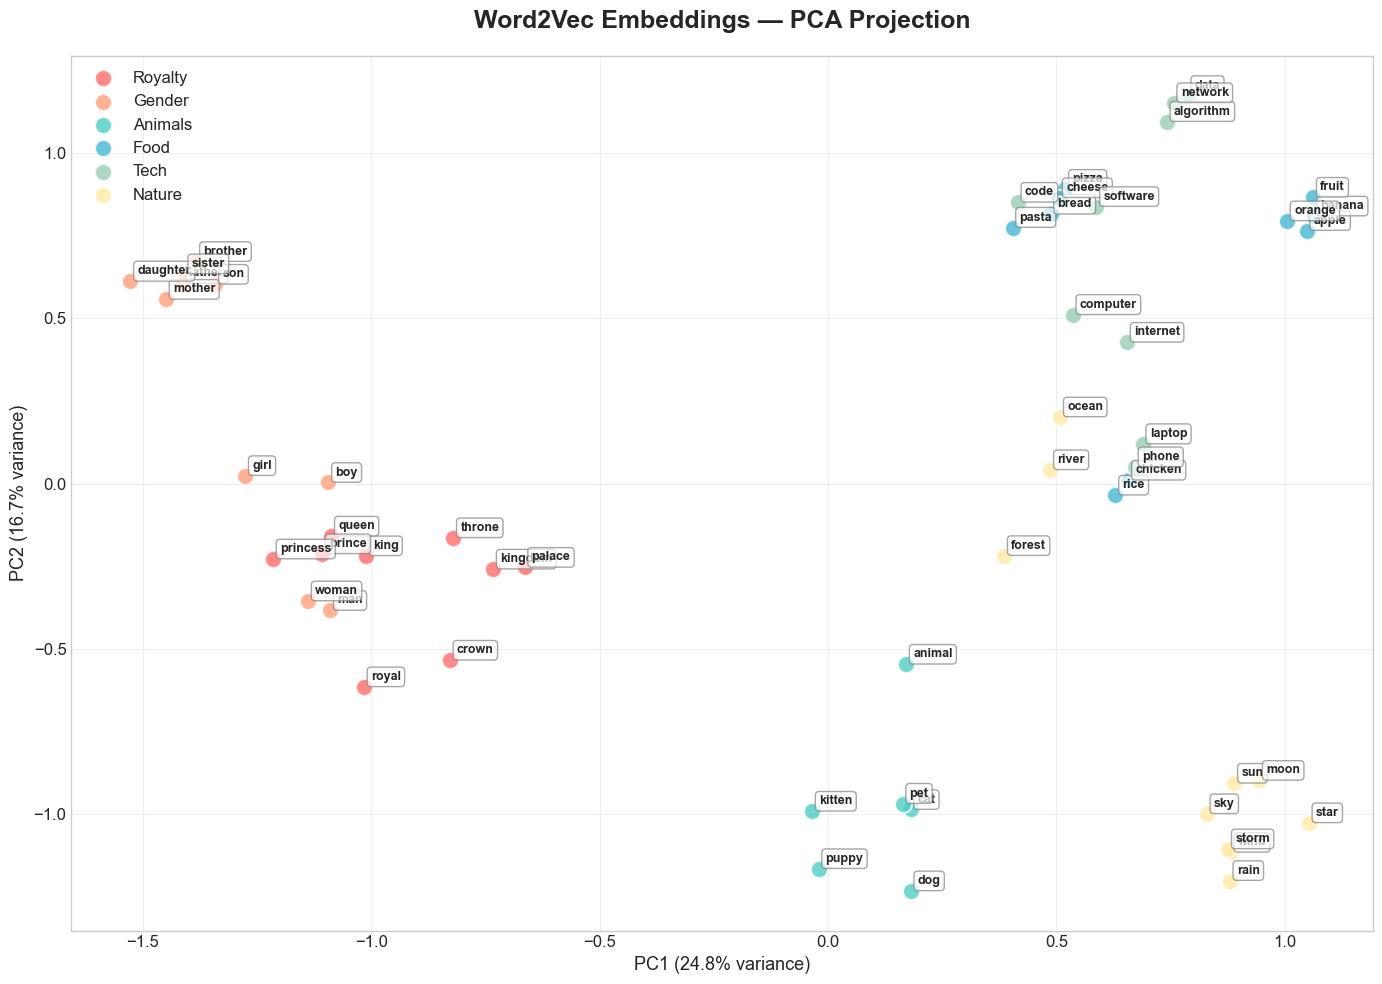

In [7]:
# Color map for categories
color_map = {
    "Royalty": "#FF6B6B",   # Red
    "Gender": "#FFA07A",    # Light Salmon
    "Animals": "#4ECDC4",   # Teal
    "Food": "#45B7D1",      # Sky Blue
    "Tech": "#96CEB4",      # Sage Green
    "Nature": "#FFEAA7",    # Yellow
}

fig, ax = plt.subplots(figsize=(14, 10))

# Plot each category
for cat in topic_words:
    mask = [c == cat for c in categories]
    x = vectors_2d_pca[mask, 0]
    y = vectors_2d_pca[mask, 1]
    ax.scatter(x, y, c=color_map[cat], s=150, alpha=0.8, edgecolors='white',
               linewidth=1.5, label=cat, zorder=3)

# Add word labels
for i, word in enumerate(words):
    ax.annotate(word, (vectors_2d_pca[i, 0], vectors_2d_pca[i, 1]),
                fontsize=9, fontweight='bold',
                xytext=(5, 5), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='gray'),
                zorder=4)

ax.set_title("Word2Vec Embeddings — PCA Projection", fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)", fontsize=13)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)", fontsize=13)
ax.legend(fontsize=12, loc='best', framealpha=0.9, edgecolor='gray')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Reduce Dimensions with t-SNE

**t-SNE** (t-distributed Stochastic Neighbor Embedding) is another dimensionality reduction method. Unlike PCA, t-SNE is non-linear and specifically designed to preserve **local neighborhood structure** — it's often better at revealing clusters.

In [11]:
# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=min(15, len(vectors) - 1),
             learning_rate='auto', init='pca')
vectors_2d_tsne = tsne.fit_transform(vectors)

print(f"✅ t-SNE complete!")

✅ t-SNE complete!


## 9. Plot t-SNE Word Embeddings

Compare this with the PCA plot above — t-SNE often creates tighter, more distinct clusters.

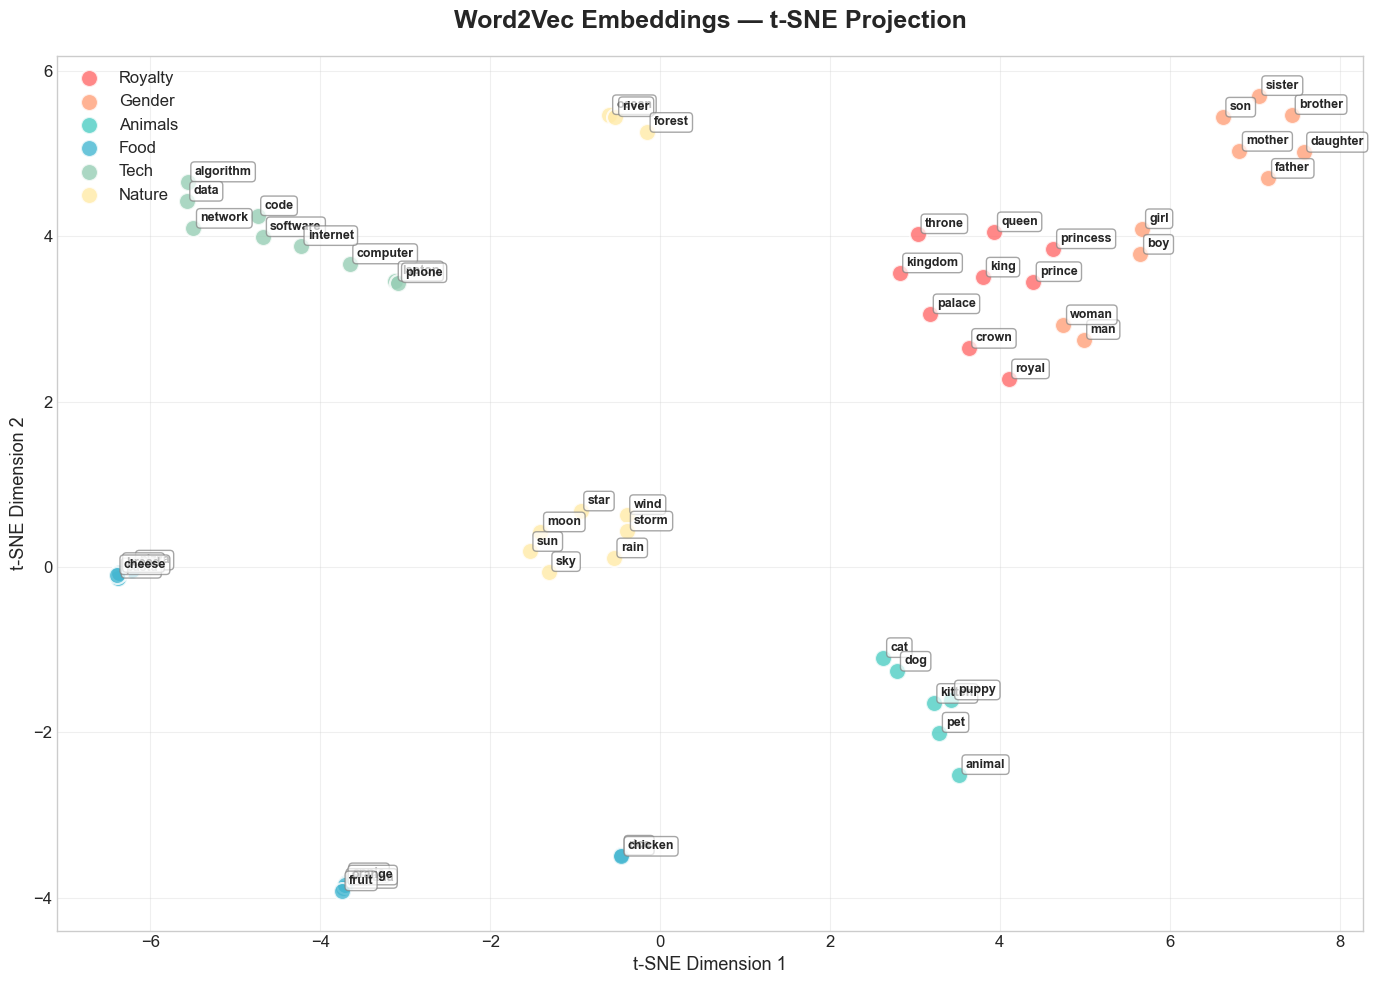

In [12]:
fig, ax = plt.subplots(figsize=(14, 10))

# Plot each category
for cat in topic_words:
    mask = [c == cat for c in categories]
    x = vectors_2d_tsne[mask, 0]
    y = vectors_2d_tsne[mask, 1]
    ax.scatter(x, y, c=color_map[cat], s=150, alpha=0.8, edgecolors='white',
               linewidth=1.5, label=cat, zorder=3)

# Add word labels
for i, word in enumerate(words):
    ax.annotate(word, (vectors_2d_tsne[i, 0], vectors_2d_tsne[i, 1]),
                fontsize=9, fontweight='bold',
                xytext=(5, 5), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='gray'),
                zorder=4)

ax.set_title("Word2Vec Embeddings — t-SNE Projection", fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel("t-SNE Dimension 1", fontsize=13)
ax.set_ylabel("t-SNE Dimension 2", fontsize=13)
ax.legend(fontsize=12, loc='best', framealpha=0.9, edgecolor='gray')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Visualize Word Analogy Arithmetic

The most famous Word2Vec result: **king - man + woman = queen**. Let's visualize this vector arithmetic with arrows showing the relationships!

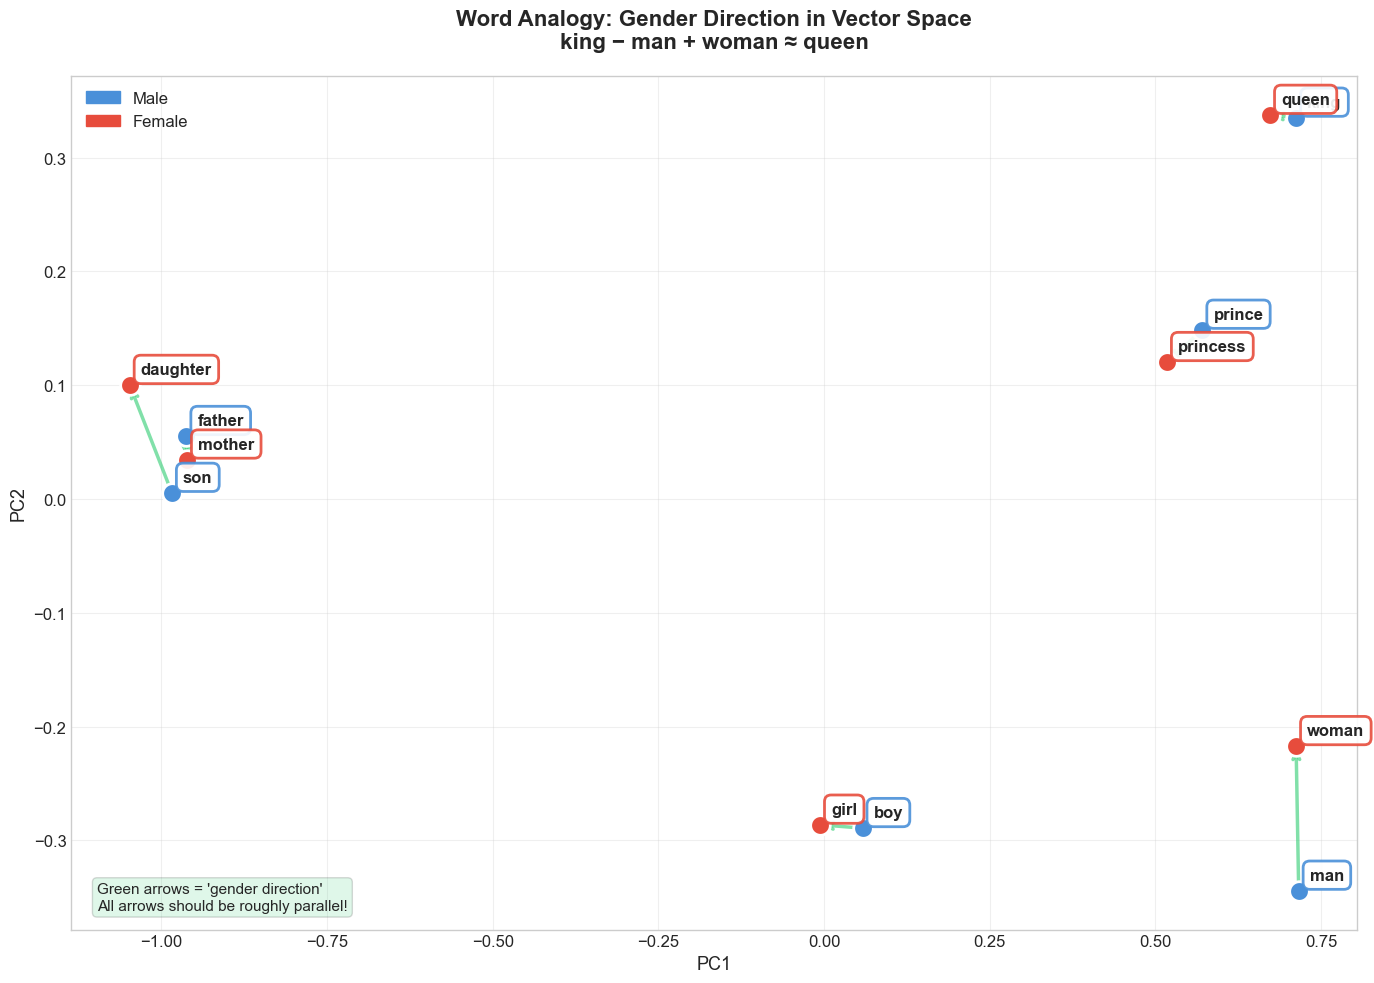

In [14]:
# Visualize the analogy: king - man + woman ≈ queen
analogy_words = ["king", "queen", "man", "woman", "prince", "princess",
                 "father", "mother", "boy", "girl", "son", "daughter"]

# Get vectors for analogy words & reduce with PCA
analogy_vecs = np.array([model.wv[w] for w in analogy_words])
pca_analogy = PCA(n_components=2)
analogy_2d = pca_analogy.fit_transform(analogy_vecs)

fig, ax = plt.subplots(figsize=(14, 10))

# Color male/female differently
male_words = {"king", "man", "prince", "father", "boy", "son"}
female_words = {"queen", "woman", "princess", "mother", "girl", "daughter"}

for i, word in enumerate(analogy_words):
    color = "#4A90D9" if word in male_words else "#E74C3C"
    ax.scatter(analogy_2d[i, 0], analogy_2d[i, 1], c=color, s=200,
               edgecolors='white', linewidth=2, zorder=5)
    ax.annotate(word, (analogy_2d[i, 0], analogy_2d[i, 1]),
                fontsize=12, fontweight='bold',
                xytext=(8, 8), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9, edgecolor=color, linewidth=2),
                zorder=6)

# Draw arrows for gender relationships (male → female)
pairs = [("king", "queen"), ("man", "woman"), ("prince", "princess"),
         ("father", "mother"), ("boy", "girl"), ("son", "daughter")]

for male, female in pairs:
    mi = analogy_words.index(male)
    fi = analogy_words.index(female)
    ax.annotate("", xy=analogy_2d[fi], xytext=analogy_2d[mi],
                arrowprops=dict(arrowstyle="->", color="#2ECC71", lw=2.5, alpha=0.6))

# Add legend
male_patch = mpatches.Patch(color="#4A90D9", label="Male")
female_patch = mpatches.Patch(color="#E74C3C", label="Female")
arrow_patch = mpatches.FancyArrow(0, 0, 1, 0, color="#2ECC71", width=0.3)
ax.legend(handles=[male_patch, female_patch],
          fontsize=12, loc='upper left', framealpha=0.9)

ax.set_title("Word Analogy: Gender Direction in Vector Space\n"
             r"king − man + woman ≈ queen", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("PC1", fontsize=13)
ax.set_ylabel("PC2", fontsize=13)
ax.grid(True, alpha=0.3)

# Add annotation box explaining the math
textstr = "Green arrows = 'gender direction'\nAll arrows should be roughly parallel!"
props = dict(boxstyle='round', facecolor='#2ECC71', alpha=0.15)
ax.text(0.02, 0.02, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='bottom', bbox=props)

plt.tight_layout()
plt.show()

## 11. Cosine Similarity Heatmap

**Cosine similarity** measures how similar two vectors are (1.0 = identical direction, 0 = unrelated, -1.0 = opposite). This heatmap shows which words the model considers similar or different.

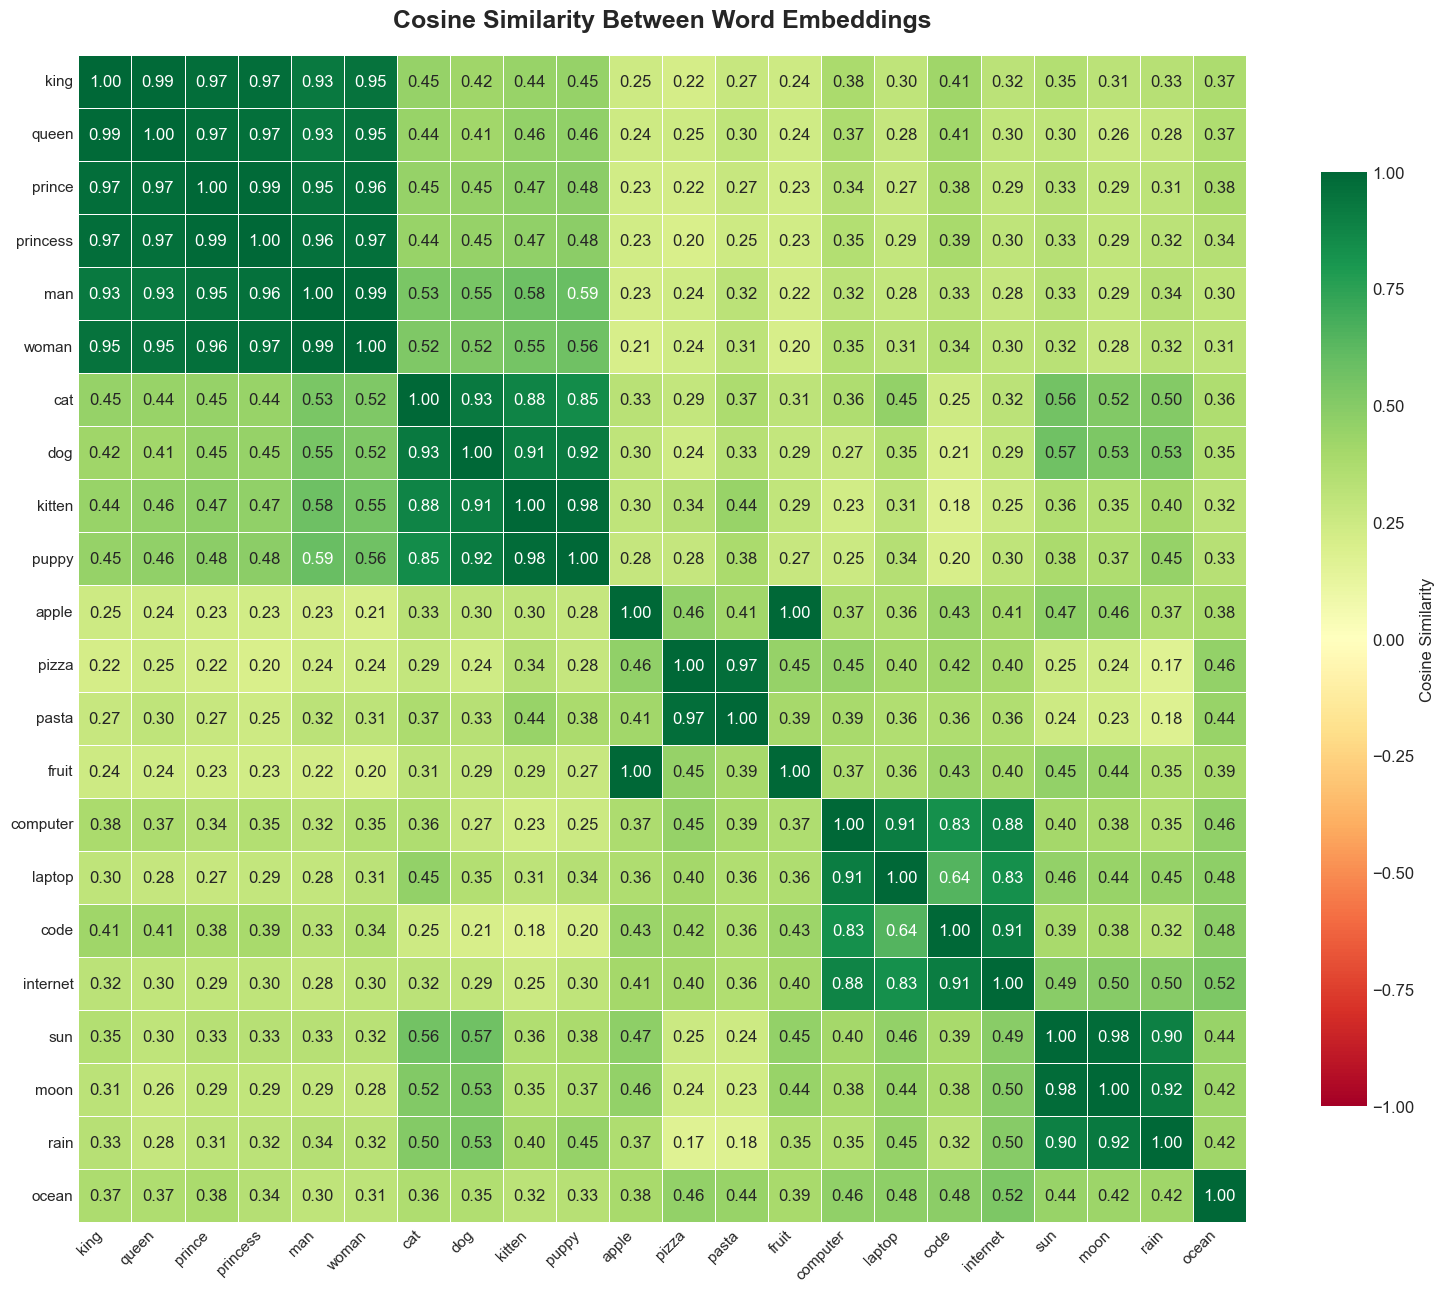

In [15]:
# Select a mix of words from different categories
heatmap_words = [
    "king", "queen", "prince", "princess", "man", "woman",
    "cat", "dog", "kitten", "puppy",
    "apple", "pizza", "pasta", "fruit",
    "computer", "laptop", "code", "internet",
    "sun", "moon", "rain", "ocean"
]

# Get vectors and compute cosine similarity matrix
heatmap_vecs = np.array([model.wv[w] for w in heatmap_words])
sim_matrix = cosine_similarity(heatmap_vecs)

# Plot
fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(sim_matrix,
            xticklabels=heatmap_words,
            yticklabels=heatmap_words,
            annot=True, fmt=".2f",
            cmap="RdYlGn",
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Cosine Similarity"},
            ax=ax,
            vmin=-1, vmax=1)

ax.set_title("Cosine Similarity Between Word Embeddings",
             fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

## Summary

### What Word2Vec Does
1. **Input**: Raw text (sentences)
2. **Process**: A shallow neural network learns to predict words from context (Skip-gram) or context from words (CBOW)
3. **Output**: A dense vector for every word in the vocabulary

### Why It's Powerful
- Similar words get **similar vectors** (cat ≈ kitten)
- Semantic relationships become **vector arithmetic** (king - man + woman = queen)
- These embeddings can be used as features in **downstream ML tasks** (sentiment analysis, classification, etc.)

### Key Limitations
- **Static embeddings**: Each word gets ONE vector regardless of context ("bank" as river bank vs. money bank)
- **No subword info**: Can't handle unseen words (solved by FastText)
- **Needs lots of data**: Our toy corpus is tiny — real Word2Vec models train on billions of words

### What Came Next
- **FastText** (2016): Handles subword info (character n-grams)
- **ELMo** (2018): Context-dependent embeddings
- **BERT / GPT** (2018-2019): Transformer-based, fully contextual — the foundation of modern NLP

Word2Vec was a **huge breakthrough** that kicked off the deep learning revolution in NLP! 🚀